In [1]:
from google.colab import files
upload=files.upload()

Saving extracted_product_info_amazon.csv to extracted_product_info_amazon.csv


In [2]:
import pandas as pd
df=pd.read_csv("extracted_product_info_amazon.csv")
df.head()

,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,23.8 Inches,FHD 1080p,16:9,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,31.5 Inches,FHD 1080p,16:9,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27 Inches,FHD 1080p,16:9,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30 Inches,FHD 1080p Ultra Wide,21:9,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,31.5 Inches,4K UHD 2160p,16:9,4.3,279.99


In [3]:
from sklearn.preprocessing import LabelEncoder
df["Screen Size"]=df["Screen Size"].apply(lambda x: (float(x.split()[0])))
df.head()

,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,23.8,FHD 1080p,16:9,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,31.5,FHD 1080p,16:9,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27.0,FHD 1080p,16:9,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30.0,FHD 1080p Ultra Wide,21:9,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,31.5,4K UHD 2160p,16:9,4.3,279.99


In [4]:
df[['width', 'height']] = df['Aspect Ratio'].str.split(":", expand=True)
df['width'] = pd.to_numeric(df['width'], errors='coerce')
df['height'] = pd.to_numeric(df['height'], errors='coerce')
df['Aspect Ratio'] = df['width'] / df['height']
df.drop(columns=['width', 'height'], inplace=True)
df.head()

,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,23.8,FHD 1080p,1.777778,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,31.5,FHD 1080p,1.777778,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27.0,FHD 1080p,1.777778,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30.0,FHD 1080p Ultra Wide,2.333333,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,31.5,4K UHD 2160p,1.777778,4.3,279.99


In [5]:
df['Price'] = df['Price'].str.replace(',', '').astype(float)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         947 non-null    object 
 1   Brand         947 non-null    object 
 2   Screen Size   947 non-null    float64
 3   Resolution    947 non-null    object 
 4   Aspect Ratio  943 non-null    float64
 5   Rating        947 non-null    object 
 6   Price         947 non-null    float64
dtypes: float64(3), object(4)
memory usage: 51.9+ KB


In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Resolution"]=le.fit_transform(df["Resolution"])

In [8]:
df.head()

,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,23.8,18,1.777778,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,31.5,18,1.777778,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27.0,18,1.777778,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30.0,19,2.333333,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,31.5,11,1.777778,4.3,279.99


In [9]:
df.drop("Title",axis=1,inplace=True)
df.head()

,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,acer,23.8,18,1.777778,4.4,94.99
1,acer,31.5,18,1.777778,4.6,259.99
2,acer,27.0,18,1.777778,4.5,99.99
3,Sceptre,30.0,19,2.333333,4.5,199.97
4,SAMSUNG,31.5,11,1.777778,4.3,279.99


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         947 non-null    object 
 1   Screen Size   947 non-null    float64
 2   Resolution    947 non-null    int64  
 3   Aspect Ratio  943 non-null    float64
 4   Rating        947 non-null    object 
 5   Price         947 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 44.5+ KB


In [11]:
df_excluded=df[df["Rating"]!="Previous"]

In [12]:
df_excluded["Rating"]=df_excluded["Rating"].astype(float)
df_excluded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 0 to 946
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         912 non-null    object 
 1   Screen Size   912 non-null    float64
 2   Resolution    912 non-null    int64  
 3   Aspect Ratio  909 non-null    float64
 4   Rating        912 non-null    float64
 5   Price         912 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 49.9+ KB


<ipython-input-12-208a0c58c7aa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_excluded["Rating"]=df_excluded["Rating"].astype(float)


In [13]:
df_excluded = df_excluded[df_excluded["Aspect Ratio"].notna()]

In [14]:
df_excluded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 909 entries, 0 to 946
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         909 non-null    object 
 1   Screen Size   909 non-null    float64
 2   Resolution    909 non-null    int64  
 3   Aspect Ratio  909 non-null    float64
 4   Rating        909 non-null    float64
 5   Price         909 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 49.7+ KB


In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df1 = df_excluded.copy()

Brand=df1["Brand"]
df1.drop("Brand", axis=1, inplace=True)

sc = StandardScaler()
df1_scaled = sc.fit_transform(df1)
df1_scaled = pd.DataFrame(df1_scaled, columns=df1.columns)

print(df1_scaled.head())

   Screen Size  Resolution  Aspect Ratio    Rating     Price
0    -0.690815   -0.064363     -0.238109 -0.178649 -0.592407
1     0.571975   -0.064363     -0.238109  0.519812  0.248927
2    -0.166019   -0.064363     -0.238109  0.170581 -0.566912
3     0.325977    0.123156      2.631478  0.170581 -0.057115
4     0.571975   -1.376992     -0.238109 -0.527880  0.350907


In [16]:
df1_scaled.head()

,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,-0.690815,-0.064363,-0.238109,-0.178649,-0.592407
1,0.571975,-0.064363,-0.238109,0.519812,0.248927
2,-0.166019,-0.064363,-0.238109,0.170581,-0.566912
3,0.325977,0.123156,2.631478,0.170581,-0.057115
4,0.571975,-1.376992,-0.238109,-0.527880,0.350907


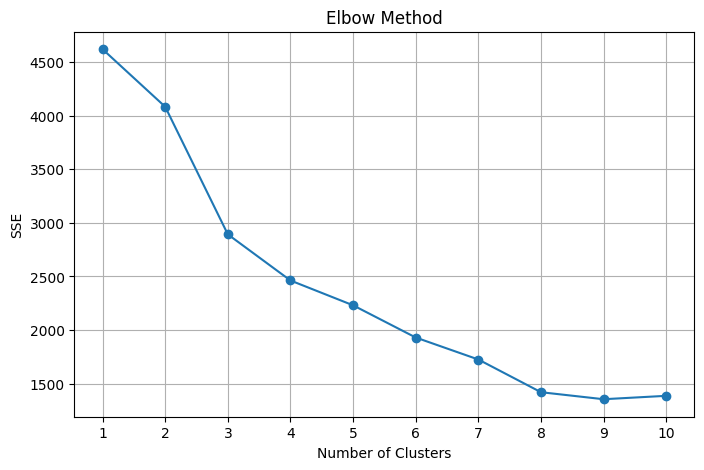

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
sse=[]
for i in range(1,11):
  model=KMeans(n_clusters=i,init="k-means++")
  model.fit(df1_scaled)
  sse.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1,11), sse, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.xticks(range(1,11))
plt.grid(True)
plt.show()

In [58]:
model=KMeans(n_clusters=3,init="k-means++")
model.fit(df1_scaled)
df1_scaled["Cluster"]=model.labels_

In [59]:
df1_scaled.head()

,Screen Size,Resolution,Aspect Ratio,Rating,Price,Cluster
0,-0.690815,-0.064363,-0.238109,-0.178649,-0.592407,2
1,0.571975,-0.064363,-0.238109,0.519812,0.248927,0
2,-0.166019,-0.064363,-0.238109,0.170581,-0.566912,2
3,0.325977,0.123156,2.631478,0.170581,-0.057115,1
4,0.571975,-1.376992,-0.238109,-0.527880,0.350907,0


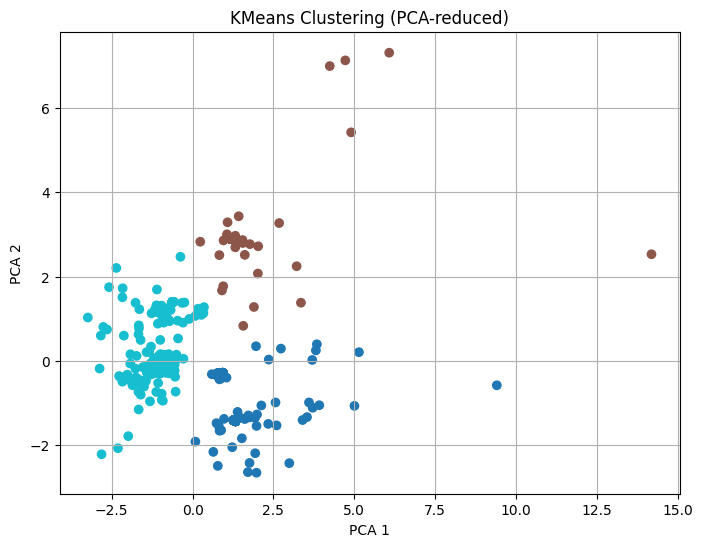

In [60]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df1_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=model.labels_, cmap='tab10')
plt.title('KMeans Clustering (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()

In [61]:
from sklearn.metrics import silhouette_score
score=silhouette_score(df1_scaled,model.labels_)
print(score)

0.5138713616259543


In [62]:
df1.shape

(909, 7)

In [63]:
df1["Brand"]=Brand
df1["Cluster"]=model.labels_

In [64]:
df1.head()

,Screen Size,Resolution,Aspect Ratio,Rating,Price,Brand,Cluster
0,23.8,18,1.777778,4.4,94.99,acer,2
1,31.5,18,1.777778,4.6,259.99,acer,0
2,27.0,18,1.777778,4.5,99.99,acer,2
3,30.0,19,2.333333,4.5,199.97,Sceptre,1
4,31.5,11,1.777778,4.3,279.99,SAMSUNG,0


In [65]:

averagePriceByCluster=df1.groupby("Cluster")["Price"].mean()

In [66]:
for cluster, avg in averagePriceByCluster.items():
  print("for {} cluster average price is {}".format(cluster+1,avg))

for 1 cluster average price is 270.40896142433235
for 2 cluster average price is 381.30573333333336
for 3 cluster average price is 145.32965794768612
